# Import Libraries #

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import TTestIndPower

## Loading dataset #

In [10]:
website = pd.read_csv("Website Landing page.csv")
website.head()

,Session_ID,User_ID,Variant,Page_Load_Time,Bounce_Flag,Session_Duration,CTA_Click,Conversion_Flag
0,1,301671,A,2.61,1,87.16,0,0
1,2,599005,B,1.84,0,243.72,1,0
2,3,988504,B,2.69,1,8.16,0,0
3,4,308709,B,2.51,1,31.55,0,0
4,5,666037,A,3.50,0,137.75,0,0


In [12]:
website.head(20)

,Session_ID,User_ID,Variant,Page_Load_Time,Bounce_Flag,Session_Duration,CTA_Click,Conversion_Flag
0,1,301671,A,2.61,1,87.16,0,0
1,2,599005,B,1.84,0,243.72,1,0
2,3,988504,B,2.69,1,8.16,0,0
3,4,308709,B,2.51,1,31.55,0,0
4,5,666037,A,3.50,0,137.75,0,0
5,6,556982,A,3.56,1,61.20,0,0
6,7,258437,A,4.13,0,190.67,0,0
7,8,320720,B,1.67,0,148.49,0,0
8,9,395109,B,2.69,1,13.50,1,0
9,10,547379,B,1.11,0,137.63,0,0


## Data Validation ##

In [19]:
website.info()
website.describe()
website.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Session_ID        100000 non-null  int64  
 1   User_ID           100000 non-null  int64  
 2   Variant           100000 non-null  object 
 3   Page_Load_Time    100000 non-null  float64
 4   Bounce_Flag       100000 non-null  int64  
 5   Session_Duration  100000 non-null  float64
 6   CTA_Click         100000 non-null  int64  
 7   Conversion_Flag   100000 non-null  int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 6.1+ MB


Session_ID          0
User_ID             0
Variant             0
Page_Load_Time      0
Bounce_Flag         0
Session_Duration    0
CTA_Click           0
Conversion_Flag     0
dtype: int64

## Split Dataset by Variant ##

In [24]:
website_A = website[website["Variant"] == "A"]
website_B = website[website["Variant"] == "B"]

# DESCRIPTIVE STATISTICS #

In [27]:
summary = website.groupby("Variant").agg(
    users=("Session_ID", "count"),
    avg_page_load_time=("Page_Load_Time", "mean"),
    avg_session_duration=("Session_Duration", "mean"),
    bounce_rate=("Bounce_Flag", "mean"),
    cta_click_rate=("CTA_Click", "mean"),
    conversion_rate=("Conversion_Flag", "mean")
)

summary

,users,avg_page_load_time,avg_session_duration,bounce_rate,cta_click_rate,conversion_rate
Variant,,,,,,
A,49934,3.202974,78.698331,0.416410,0.276165,0.033745
B,50066,2.601626,118.826037,0.319878,0.381776,0.068649


## T-TEST (SESSION DURATION) ##

### Is average session duration significantly different between Variant A and B? ###

In [31]:
t_stat, t_pvalue = stats.ttest_ind(
    website_A["Session_Duration"],
    website_B["Session_Duration"],
    equal_var=False
)

t_stat, t_pvalue

(-90.39763161689115, 0.0)

### Interpretation ###

In [34]:
if t_pvalue < 0.05:
    print("Statistically significant difference in session duration")
else:
    print("No statistically significant difference in session duration")

Statistically significant difference in session duration


## F-TEST (VARIANCE COMPARISON) ##

### Is session duration variability different across variants? ###

In [38]:
var_A = np.var(website_A["Session_Duration"], ddof=1)
var_B = np.var(website_B["Session_Duration"], ddof=1)

F_stat = var_A / var_B
df1 = len(website_A) - 1
df2 = len(website_B) - 1

p_value_f = 1 - stats.f.cdf(F_stat, df1, df2)

F_stat, p_value_f

(0.5507759648454211, 1.0)

## Z-TEST (CONVERSION RATE) ##

### Did conversion rate improve in Variant B? ###

conversions = np.array([
    website_A["Conversion_Flag"].sum(),
    website_B["Conversion_Flag"].sum()
])

samples = np.array([
    len(website_A),
    len(website_B)
])

z_stat, z_pvalue = proportions_ztest(conversions, samples)

z_stat, z_pvalue

## CHI-SQUARE TEST (BOUNCE RATE) ##

### Is bounce behavior dependent on landing page variant? ###

In [46]:
contingency_table = pd.crosstab(
    website["Variant"],
    website["Bounce_Flag"]
)

chi2_stat, chi2_pvalue, dof, expected = stats.chi2_contingency(contingency_table)

chi2_stat, chi2_pvalue

(1001.144247309674, 1.0128564902528653e-219)

## ANOVA (PAGE LOAD TIME) ##

### Does page load time differ across variants? ###

In [50]:
anova_stat, anova_pvalue = stats.f_oneway(
    website_A["Page_Load_Time"],
    website_B["Page_Load_Time"]
)

anova_stat, anova_pvalue

(18141.42483543439, 0.0)

## EFFECT SIZE (COHEN’S d) ##

In [53]:
mean_diff = website_B["Session_Duration"].mean() - website_A["Session_Duration"].mean()
pooled_std = np.sqrt(
    (var_A + var_B) / 2
)
cohens_d = mean_diff / pooled_std
cohens_d

0.571616003301819

## CONFIDENCE INTERVAL (MEAN DIFFERENCE) ##

In [56]:
confidence_level = 0.95
alpha = 1 - confidence_level

mean_A = website_A["Session_Duration"].mean()
mean_B = website_B["Session_Duration"].mean()

se = np.sqrt(var_A/len(website_A) + var_B/len(website_B))

margin = stats.norm.ppf(1 - alpha/2) * se

(mean_B - mean_A - margin, mean_B - mean_A + margin)

(39.25767335055493, 40.99773791679366)

# POWER ANALYSIS #

In [59]:
analysis = TTestIndPower()

power = analysis.solve_power(
    effect_size=cohens_d,
    nobs1=len(website_A),
    ratio=len(website_B)/len(website_A),
    alpha=0.05
)
power

1.0

## Conversion Rate By Variant ##

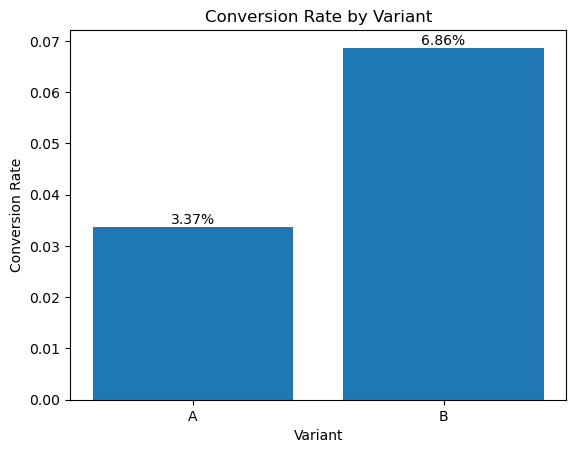

In [82]:
conversion_rates = website.groupby("Variant")["Conversion_Flag"].mean()

plt.figure()
bars = plt.bar(
    conversion_rates.index,
    conversion_rates.values
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2%}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xlabel("Variant")
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate by Variant")
plt.show()

## Session Duration Distribution ##

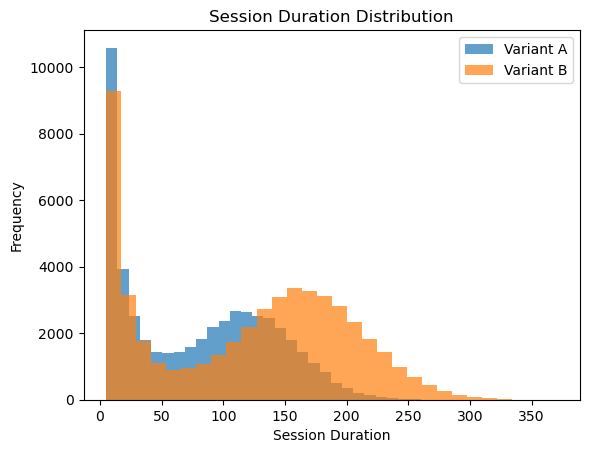

In [84]:
plt.figure()
plt.hist(website_A["Session_Duration"], bins=30, alpha=0.7, label="Variant A")
plt.hist(website_B["Session_Duration"], bins=30, alpha=0.7, label="Variant B")
plt.xlabel("Session Duration")
plt.ylabel("Frequency")
plt.title("Session Duration Distribution")
plt.legend()
plt.show()

## Bounce Rate by Variant ##

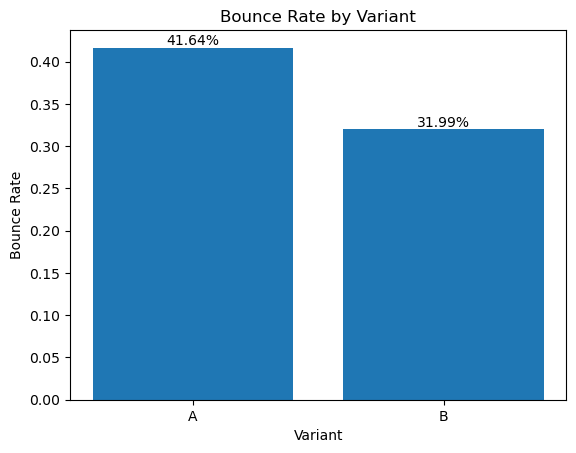

In [93]:
bounce_rates = website.groupby("Variant")["Bounce_Flag"].mean()

plt.figure()
bars = plt.bar(
    bounce_rates.index,
    bounce_rates.values
)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2%}",
        ha="center",
        va="bottom",
        fontsize=10
    )
plt.xlabel("Variant")
plt.ylabel("Bounce Rate")
plt.title("Bounce Rate by Variant")
plt.show()

## Page Load Time Distribution ##

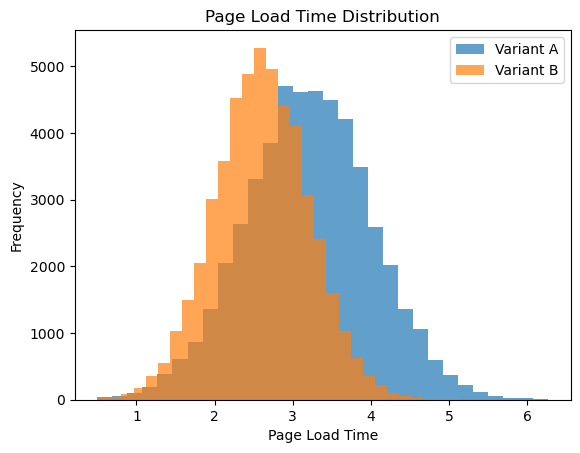

In [96]:
plt.figure()
plt.hist(website_A["Page_Load_Time"], bins=30, alpha=0.7, label="Variant A")
plt.hist(website_B["Page_Load_Time"], bins=30, alpha=0.7, label="Variant B")
plt.xlabel("Page Load Time")
plt.ylabel("Frequency")
plt.title("Page Load Time Distribution")
plt.legend()
plt.show()

# CUPED VARIANCE REDUCTION #

## Pre-experiment covariate: Page_Load_Time ##

In [114]:
theta = np.cov(
    website["Session_Duration"],
    website["Page_Load_Time"]
)[0, 1] / np.var(website["Page_Load_Time"])

website["Session_Duration_CUPED"] = (
    website["Session_Duration"]
    - theta * (website["Page_Load_Time"] - website["Page_Load_Time"].mean())
)

## T-test on CUPED-adjusted metric ##

In [105]:
t_cuped, p_cuped = stats.ttest_ind(
    website[website["Variant"] == "A"]["Session_Duration_CUPED"],
    website[website["Variant"] == "B"]["Session_Duration_CUPED"],
    equal_var=False
)

In [107]:
print("CUPED T-statistic:", t_cuped)
print("CUPED p-value:", p_cuped)

CUPED T-statistic: -75.81677697874795
CUPED p-value: 0.0


## BAYESIAN A/B TESTING ##

### Beta-Binomial Bayesian Model for Conversion Rate ###

In [111]:
alpha_prior = 1
beta_prior = 1

conv_A = website_A["Conversion_Flag"].sum()
conv_B = website_B["Conversion_Flag"].sum()

n_A = len(website_A)
n_B = len(website_B)

posterior_A = np.random.beta(
    alpha_prior + conv_A,
    beta_prior + n_A - conv_A,
    100000
)

posterior_B = np.random.beta(
    alpha_prior + conv_B,
    beta_prior + n_B - conv_B,
    100000
)

## Probability that Variant B is better than Variant A ##

In [117]:
prob_B_better = np.mean(posterior_B > posterior_A)
print("Probability Variant B is better than A:", prob_B_better)

Probability Variant B is better than A: 1.0


## Posterior Distribution Visualization ##

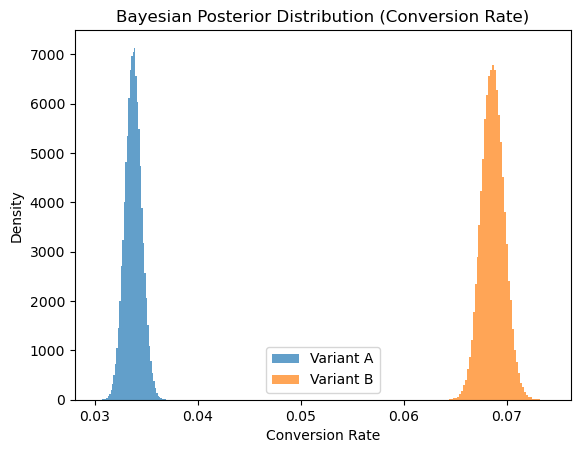

In [120]:
plt.figure()
plt.hist(posterior_A, bins=50, alpha=0.7, label="Variant A")
plt.hist(posterior_B, bins=50, alpha=0.7, label="Variant B")
plt.xlabel("Conversion Rate")
plt.ylabel("Density")
plt.title("Bayesian Posterior Distribution (Conversion Rate)")
plt.legend()
plt.show()

## Business assumptions ##

In [123]:
REVENUE_PER_CONVERSION = 5000
COST_PER_SESSION = 50

## Profit Formula ##
## Profit=(Conversion×Revenue)−Cost ##

### Profit Calculation Code (Variant-wise) ###

In [127]:
website["Revenue"] = website["Conversion_Flag"] * REVENUE_PER_CONVERSION
website["Cost"] = COST_PER_SESSION
website["Profit"] = website["Revenue"] - website["Cost"]

## Average Profit per User ##

In [130]:
profit_summary = website.groupby("Variant").agg(
    users=("Session_ID", "count"),
    avg_conversion_rate=("Conversion_Flag", "mean"),
    avg_profit_per_user=("Profit", "mean"),
    total_profit=("Profit", "sum")
)

profit_summary

,users,avg_conversion_rate,avg_profit_per_user,total_profit
Variant,,,,
A,49934,0.033745,118.722714,5928300
B,50066,0.068649,293.246914,14681700


### Profit Lift (Variant B vs A) ###

In [134]:
profit_lift = (
    profit_summary.loc["B", "avg_profit_per_user"]
    - profit_summary.loc["A", "avg_profit_per_user"]
)
profit_lift

174.52420009096622

### Interpretation ###

### 1) Positive profit lift → Variant B is better financially ###
### 2) Negative profit lift → Don’t deploy, even if conversions are higher ###

## Statistical Test on Profit (T-Test) ##

In [140]:
t_profit, p_profit = stats.ttest_ind(
    website[website["Variant"] == "A"]["Profit"],
    website[website["Variant"] == "B"]["Profit"],
    equal_var=False
)

t_profit, p_profit

(-25.12463257116746, 8.02392283984773e-139)

## Confidence Interval for Profit Lift ##

In [144]:
profit_A = website[website["Variant"] == "A"]["Profit"]
profit_B = website[website["Variant"] == "B"]["Profit"]

mean_diff = profit_B.mean() - profit_A.mean()

var_A = profit_A.var(ddof=1)
var_B = profit_B.var(ddof=1)

se = np.sqrt(var_A/len(profit_A) + var_B/len(profit_B))

margin = stats.norm.ppf(0.975) * se

(mean_diff - margin, mean_diff + margin)

(160.90962699661387, 188.13877318531857)

## Profit Visualization ##

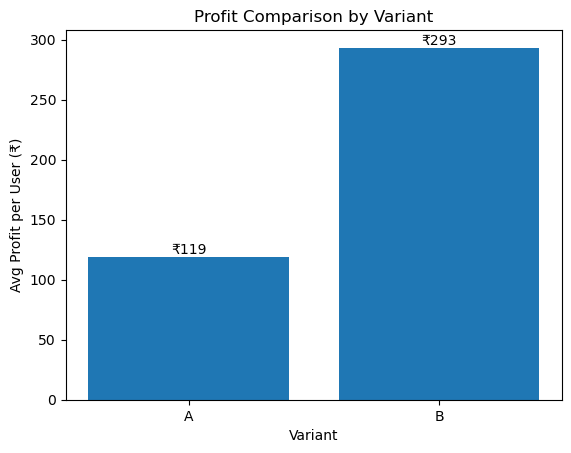

In [147]:
plt.figure()
plt.bar(
    profit_summary.index,
    profit_summary["avg_profit_per_user"]
)

for i, value in enumerate(profit_summary["avg_profit_per_user"]):
    plt.text(i, value, f"₹{value:,.0f}", ha="center", va="bottom")

plt.xlabel("Variant")
plt.ylabel("Avg Profit per User (₹)")
plt.title("Profit Comparison by Variant")
plt.show()

## Define known qunatities from Data ##

In [150]:
COST_PER_SESSION = 50

## Compute Conversion Rates ##

In [155]:
cr_A = website[website["Variant"] == "A"]["Conversion_Flag"].mean()
cr_B = website[website["Variant"] == "B"]["Conversion_Flag"].mean()
cr_A, cr_B

(0.03374454279649137, 0.06864938281468462)

## Break-Even Revenue-Calculation ##

In [158]:
break_even_revenue = COST_PER_SESSION / (cr_B - cr_A)
break_even_revenue

1432.4660985106589

### Business metrics ##

In [164]:
business_metrics = website.groupby("Variant").agg(
    avg_conversion_rate=("Conversion_Flag", "mean"),
    avg_profit_per_user=("Profit", "mean"),
    total_profit=("Profit", "sum")
).reset_index()

business_metrics.to_csv(
    "website_ab_test_business_metrics.csv",
    index=False
)

## Conversion table ##

In [167]:
website.groupby("Variant").agg(
    users=("Session_ID", "count"),
    conversions=("Conversion_Flag", "sum"),
    conversion_rate=("Conversion_Flag", "mean")
)

,users,conversions,conversion_rate
Variant,,,
A,49934,1685,0.033745
B,50066,3437,0.068649


## BAYESIAN PROFIT MODEL ##

## Bayesian Setup ##

In [174]:
REVENUE_PER_CONVERSION = 5000
COST_PER_SESSION = 50

## Generate Bayesian Posterior for Conversion Rates ##

In [177]:
alpha_prior = 1
beta_prior = 1

conv_A = website[website["Variant"] == "A"]["Conversion_Flag"].sum()
conv_B = website[website["Variant"] == "B"]["Conversion_Flag"].sum()

n_A = len(website[website["Variant"] == "A"])
n_B = len(website[website["Variant"] == "B"])

posterior_cr_A = np.random.beta(
    alpha_prior + conv_A,
    beta_prior + n_A - conv_A,
    100000
)

posterior_cr_B = np.random.beta(
    alpha_prior + conv_B,
    beta_prior + n_B - conv_B,
    100000
)

In [183]:
print(conv_A)
print(conv_B)

1685
3437


## Convert Conversion Posterior → Profit Posterior ##
### Profit=(CR×R)-C ###

In [181]:
profit_A = posterior_cr_A * REVENUE_PER_CONVERSION - COST_PER_SESSION
profit_B = posterior_cr_B * REVENUE_PER_CONVERSION - COST_PER_SESSION

In [185]:
print(profit_A)
print(profit_B)

[115.73112127 117.20052244 124.9685616  ... 118.80999738 121.4941861
 110.84665505]
[294.77968418 291.96544167 292.22126393 ... 293.61278517 298.13664945
 288.94654153]


### Which Variant is more profitable ###

In [189]:
prob_B_more_profitable = np.mean(profit_B > profit_A)
prob_B_more_profitable

1.0

## Bayesian profit modeling shows a near-certain probability that Variant B delivers higher profit per user, making it the dominant decision under uncertainty. ##

## Bayesian Profit Distribution ##

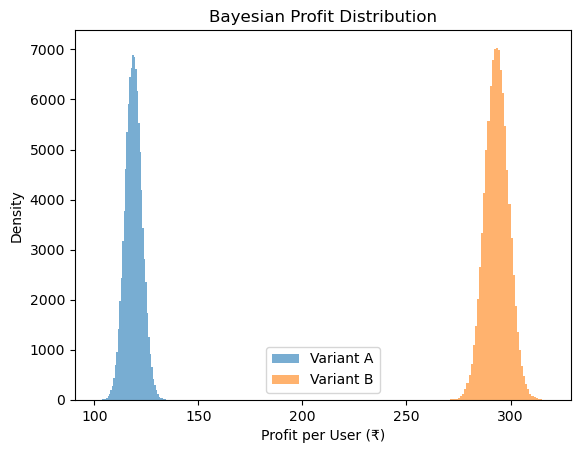

In [193]:
plt.figure()
plt.hist(profit_A, bins=50, alpha=0.6, label="Variant A")
plt.hist(profit_B, bins=50, alpha=0.6, label="Variant B")
plt.xlabel("Profit per User (₹)")
plt.ylabel("Density")
plt.title("Bayesian Profit Distribution")
plt.legend()
plt.show()